In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sassypotatosona/seaonal-agricultural-data/seasonal_agriculture_performance_dataset (2).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/sassypotatosona/seaonal-agricultural-data/seasonal_agriculture_performance_dataset (2).csv


In [4]:
df = pd.read_csv('/kaggle/input/datasets/sassypotatosona/seaonal-agricultural-data/seasonal_agriculture_performance_dataset (2).csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Rows: 4000
Columns: 28

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data Types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                       

In [6]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


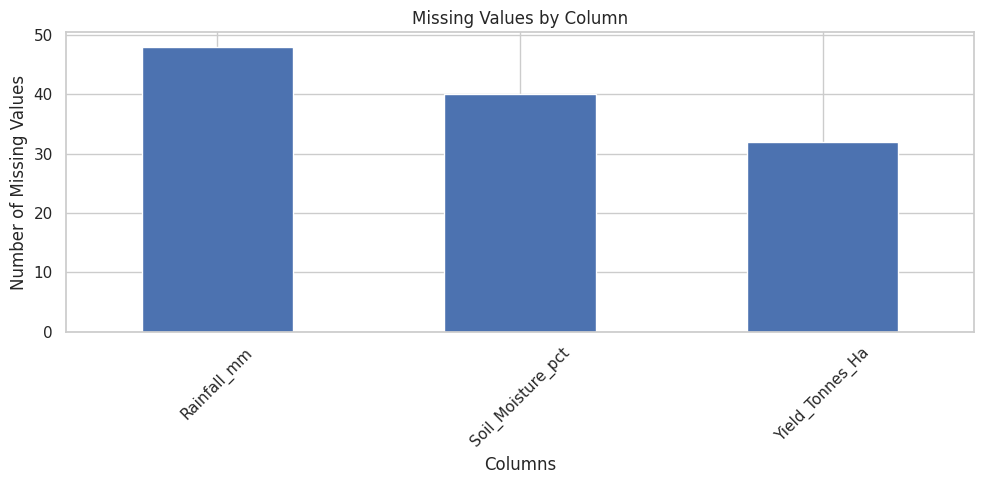

In [7]:
plt.figure(figsize=(10,5))

missing.plot(kind='bar')

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print("Total missing values after cleaning:",
      df.isnull().sum().sum())

Total missing values after cleaning: 0


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


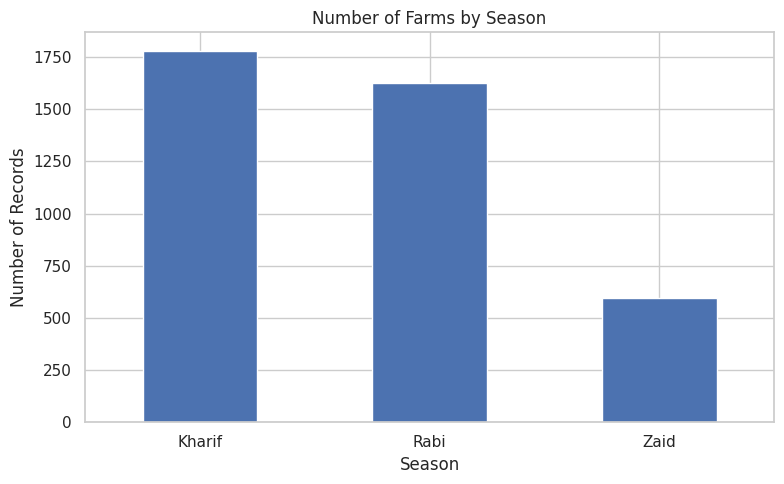

In [11]:
season_counts = df['Season'].value_counts()

plt.figure(figsize=(8,5))

season_counts.plot(kind='bar')

plt.title("Number of Farms by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64


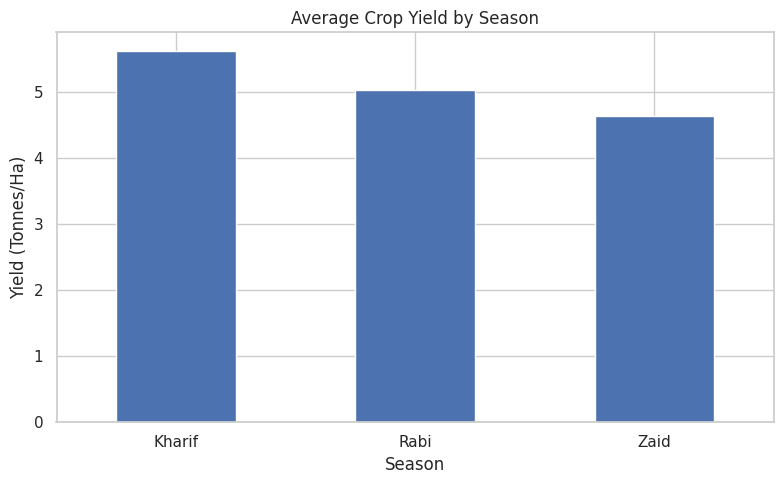

In [12]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(
    ascending=False
)

print(season_yield)

plt.figure(figsize=(8,5))

season_yield.plot(kind='bar')

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

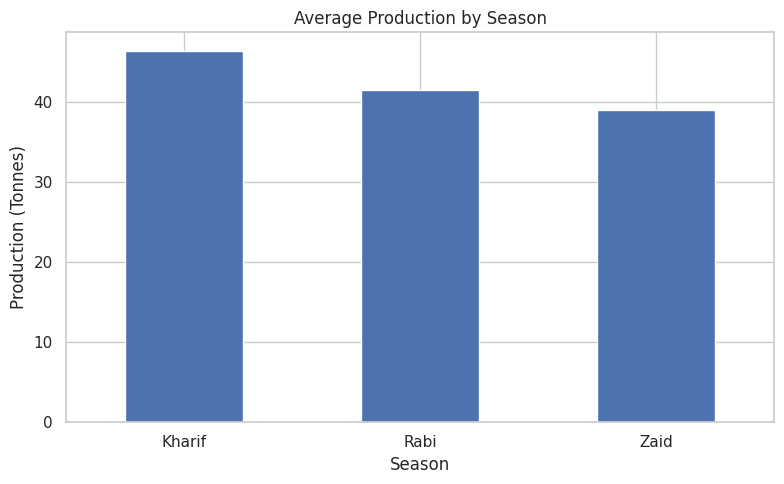

In [13]:
season_production = df.groupby('Season')['Production_Tonnes'].mean()

plt.figure(figsize=(8,5))

season_production.plot(kind='bar')

plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Production (Tonnes)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [14]:
financial = df.groupby('Season')[
    ['Revenue_INR', 'Total_Cost_INR', 'Profit_INR']
].mean()

print(financial.round(2))

        Revenue_INR  Total_Cost_INR  Profit_INR
Season                                         
Kharif    710719.06       531804.41   178914.65
Rabi      601526.05       513836.58    87689.47
Zaid      519171.90       543976.73   -24804.82


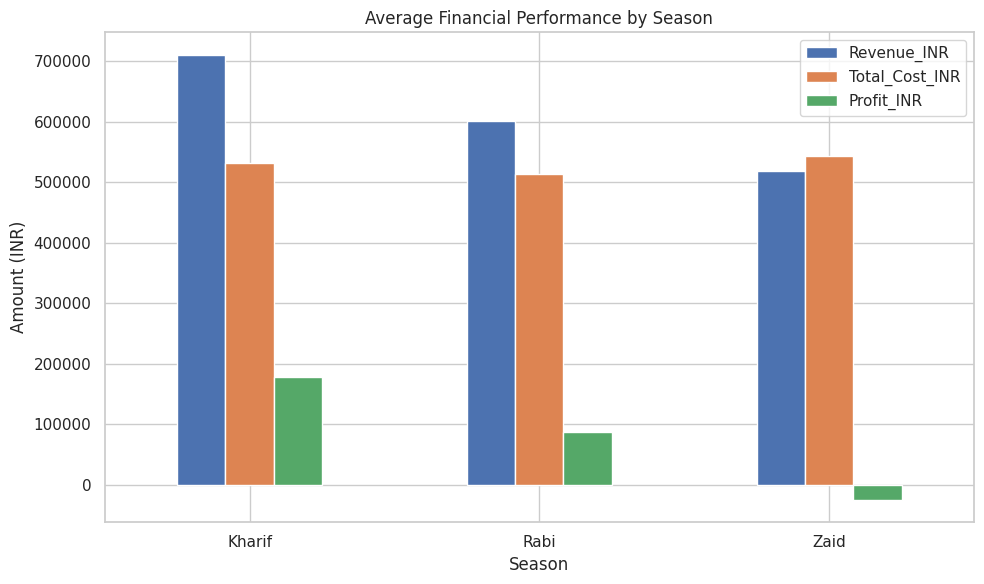

In [15]:
financial.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Average Financial Performance by Season")
plt.xlabel("Season")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Season
Kharif    6102.201237
Rabi      5846.987093
Zaid      6419.893939
Name: Water_Used_m3, dtype: float64


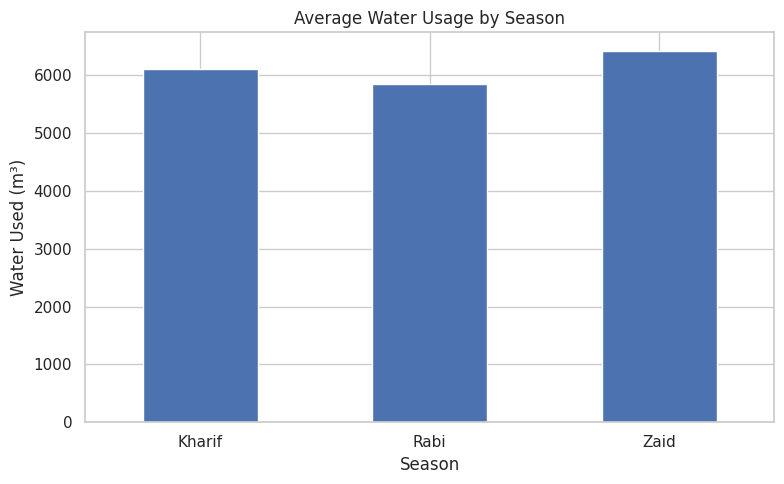

In [16]:
water = df.groupby('Season')['Water_Used_m3'].mean()

print(water)

plt.figure(figsize=(8,5))

water.plot(kind='bar')

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Season
Kharif    5.891834
Rabi      5.186122
Zaid      4.413239
Name: Water_Efficiency_t_per_1000m3, dtype: float64


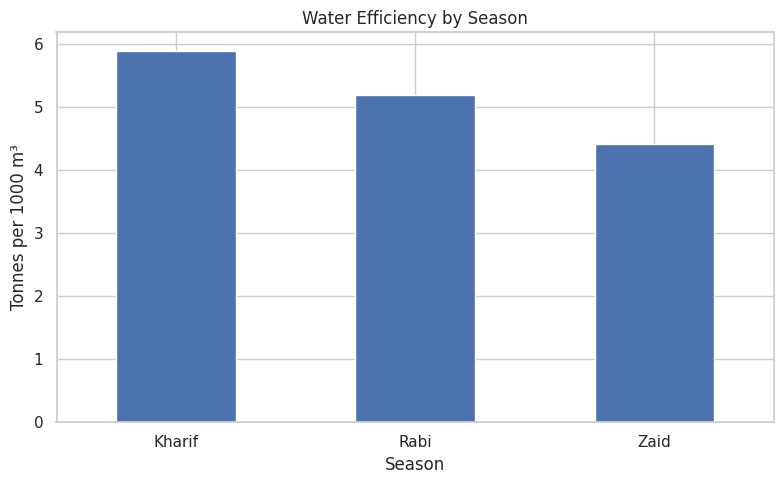

In [17]:
water_efficiency = df.groupby('Season')[
    'Water_Efficiency_t_per_1000m3'
].mean()

print(water_efficiency)

plt.figure(figsize=(8,5))

water_efficiency.plot(kind='bar')

plt.title("Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Tonnes per 1000 m³")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

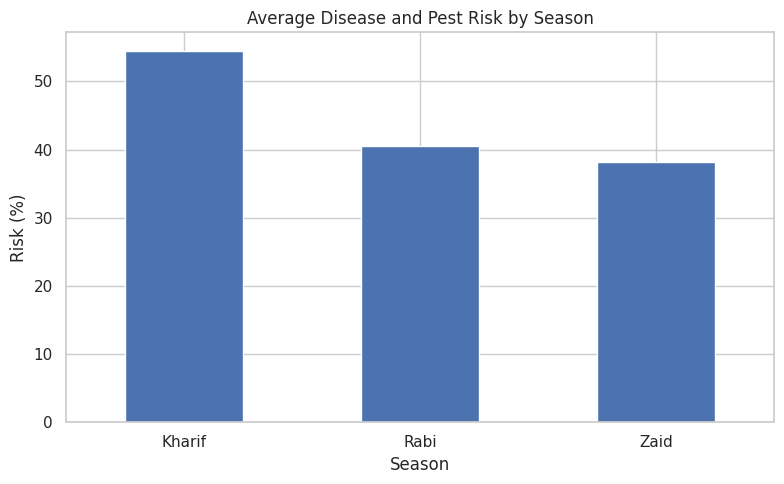

In [18]:
risk = df.groupby('Season')['Disease_Pest_Risk_pct'].mean()

plt.figure(figsize=(8,5))

risk.plot(kind='bar')

plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [19]:
crop_performance = df.groupby('Crop').agg({
    'Yield_Tonnes_Ha':'mean',
    'Profit_INR':'mean'
}).sort_values(
    'Profit_INR',
    ascending=False
)

print(crop_performance.round(2))

           Yield_Tonnes_Ha  Profit_INR
Crop                                  
Sugarcane            46.64   817187.99
Chilli                1.54   750878.34
Cotton                1.23   124546.92
Groundnut             1.32    44858.12
Pulses                0.92    -4238.05
Maize                 2.71   -83978.33
Rice                  2.43  -102213.50
Wheat                 2.11  -123398.34


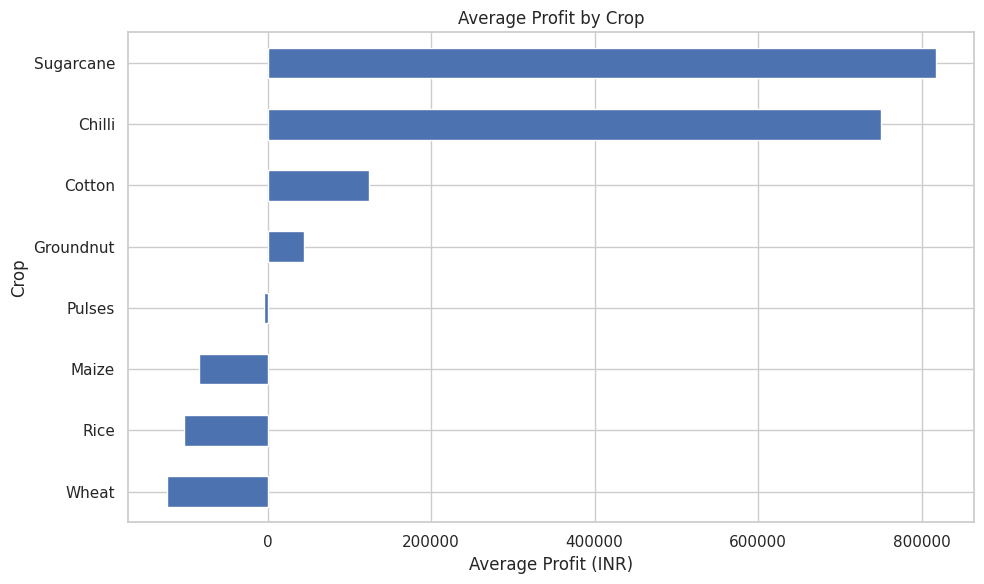

In [20]:
plt.figure(figsize=(10,6))

crop_performance['Profit_INR'].sort_values().plot(kind='barh')

plt.title("Average Profit by Crop")
plt.xlabel("Average Profit (INR)")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

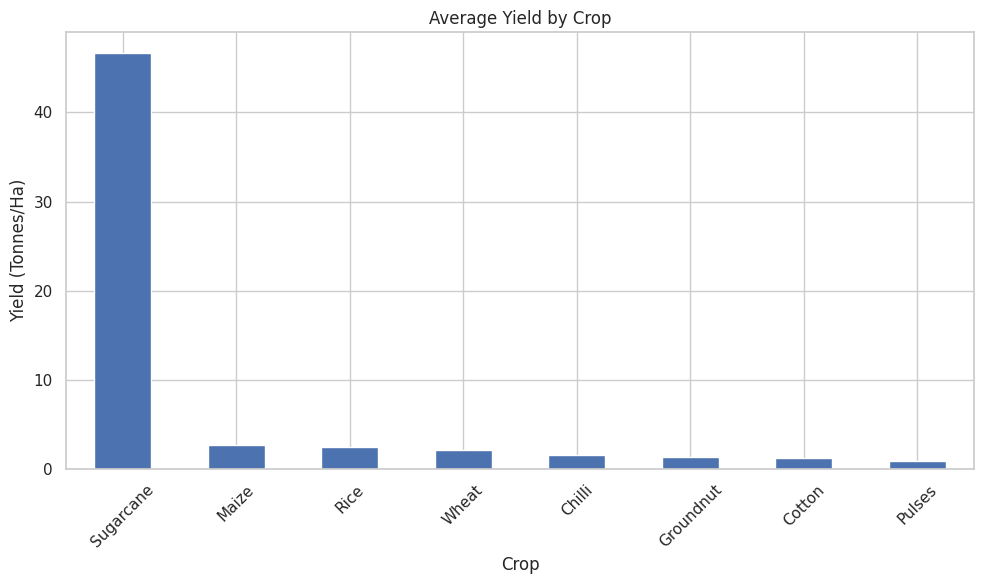

In [21]:
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(10,6))

crop_yield.plot(kind='bar')

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [22]:
state_performance = df.groupby('State').agg({
    'Yield_Tonnes_Ha':'mean',
    'Profit_INR':'mean'
}).sort_values(
    'Profit_INR',
    ascending=False
)

print(state_performance.round(2))

                Yield_Tonnes_Ha  Profit_INR
State                                      
Punjab                     6.12   136025.64
Maharashtra                5.02   135428.86
Karnataka                  5.69   119422.34
Tamil Nadu                 4.88   117744.75
Gujarat                    5.66   117568.24
Telangana                  5.04   108829.62
Madhya Pradesh             4.99    86840.76
Andhra Pradesh             4.63    73453.53


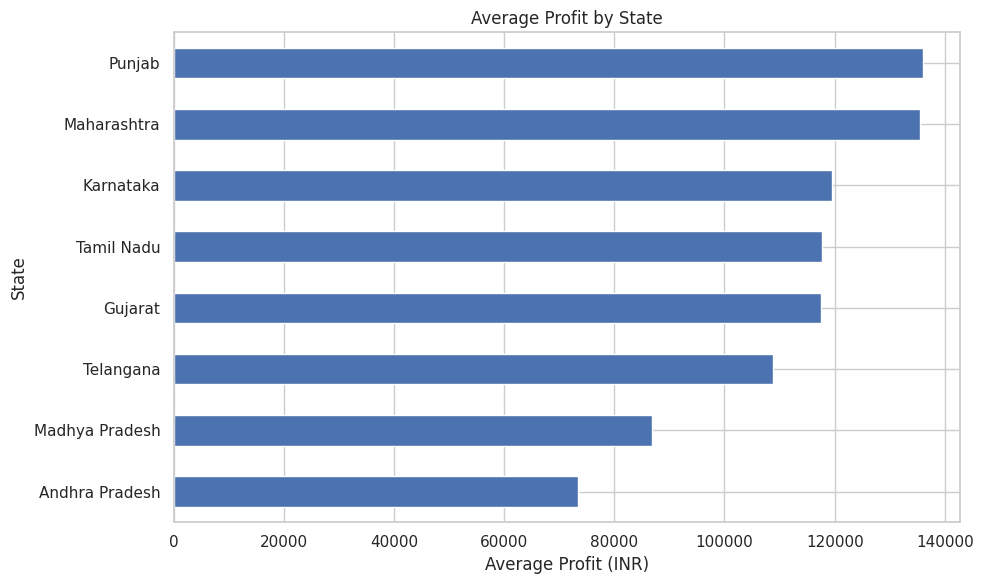

In [23]:
plt.figure(figsize=(10,6))

state_performance['Profit_INR'].sort_values().plot(kind='barh')

plt.title("Average Profit by State")
plt.xlabel("Average Profit (INR)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

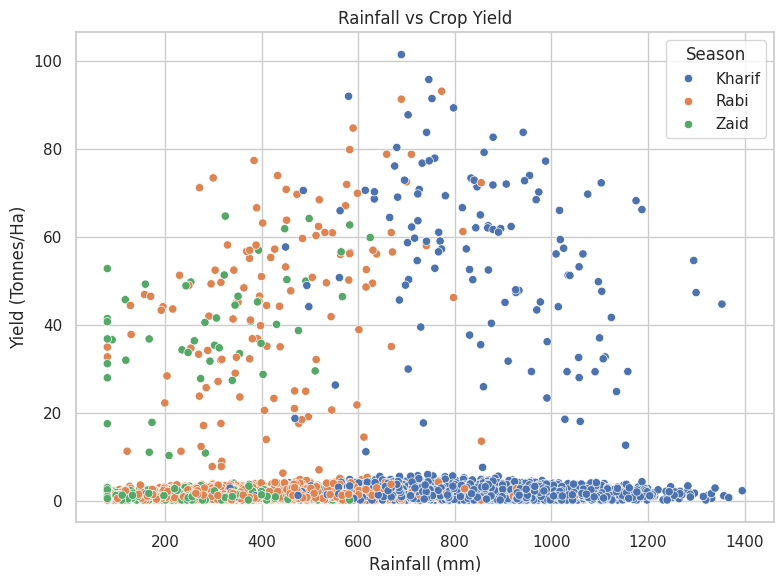

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

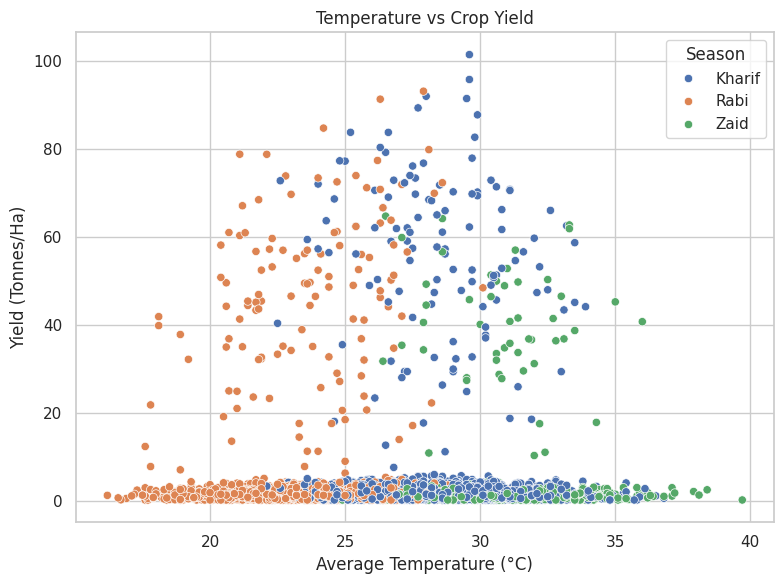

In [25]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title("Temperature vs Crop Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

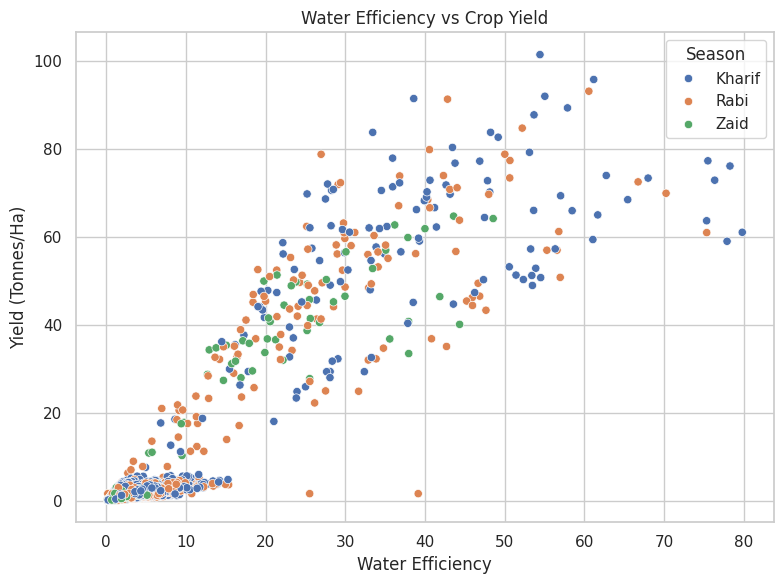

In [26]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Water_Efficiency_t_per_1000m3',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title("Water Efficiency vs Crop Yield")
plt.xlabel("Water Efficiency")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

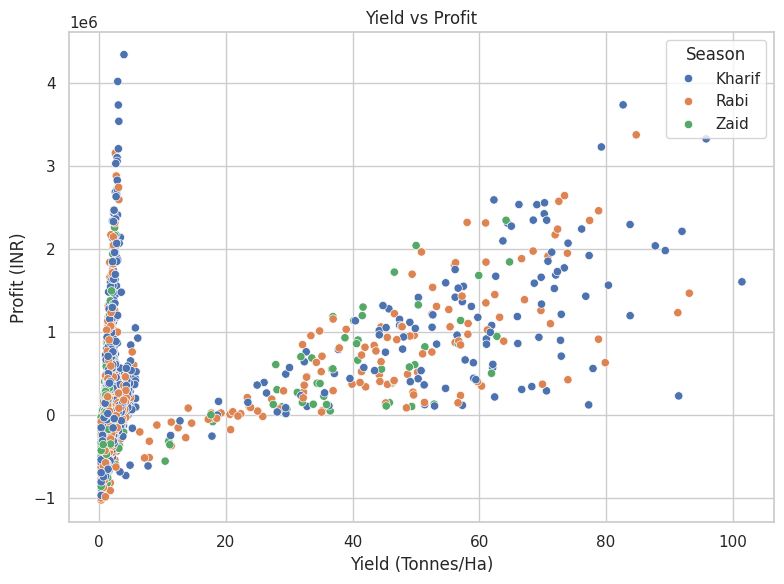

In [27]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Yield_Tonnes_Ha',
    y='Profit_INR',
    hue='Season'
)

plt.title("Yield vs Profit")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.show()

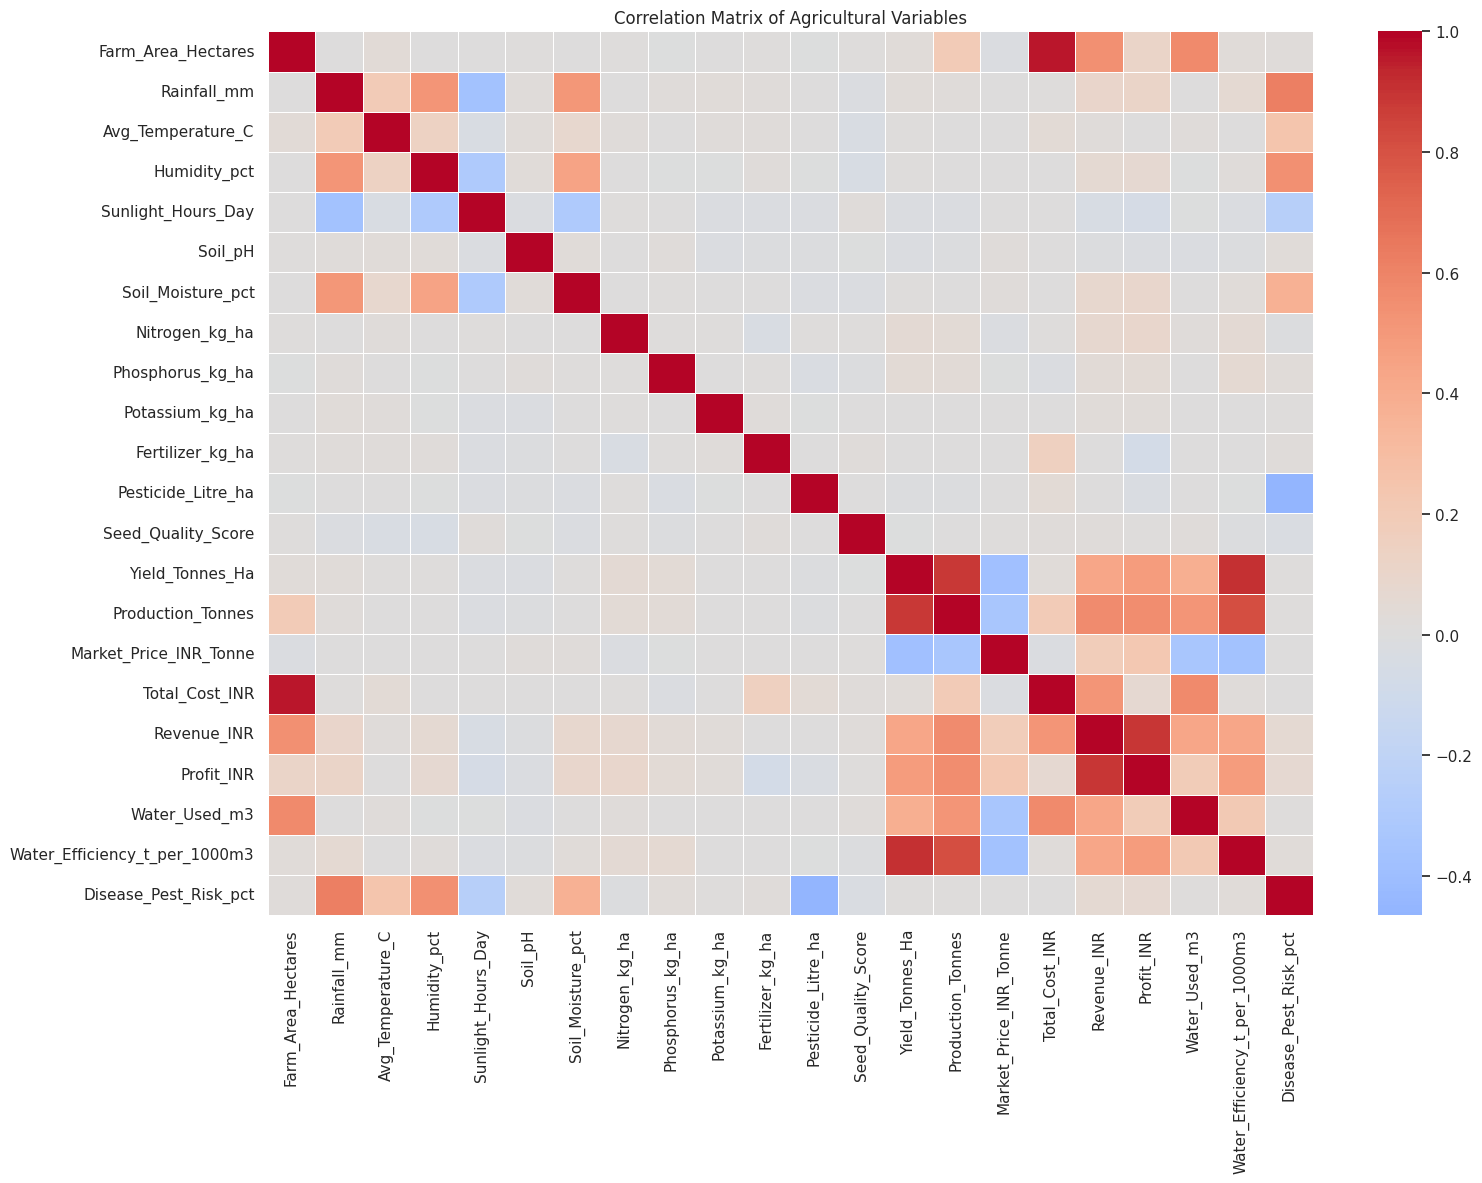

In [28]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Agricultural Variables")

plt.tight_layout()
plt.show()

In [29]:
yield_corr = corr['Yield_Tonnes_Ha'].sort_values(
    ascending=False
)

print(yield_corr)

Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.912568
Production_Tonnes                0.882813
Profit_INR                       0.488466
Revenue_INR                      0.432152
Water_Used_m3                    0.386294
Nitrogen_kg_ha                   0.053149
Phosphorus_kg_ha                 0.047941
Rainfall_mm                      0.030951
Total_Cost_INR                   0.030622
Farm_Area_Hectares               0.030203
Disease_Pest_Risk_pct            0.014292
Humidity_pct                     0.012297
Soil_Moisture_pct                0.010999
Avg_Temperature_C                0.009996
Potassium_kg_ha                  0.003382
Fertilizer_kg_ha                 0.000018
Seed_Quality_Score              -0.007209
Pesticide_Litre_ha              -0.007779
Sunlight_Hours_Day              -0.015341
Soil_pH                         -0.020672
Market_Price_INR_Tonne          -0.382607
Name: Yield_Tonnes_Ha, dtype: float64


In [30]:
season_crop_yield = pd.pivot_table(
    df,
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

print(season_crop_yield.round(2))

Season     Kharif   Rabi   Zaid
Crop                           
Chilli       1.73   1.47   1.20
Cotton       1.37   1.20   0.96
Groundnut    1.48   1.23   1.04
Maize        2.97   2.60   2.29
Pulses       1.04   0.88   0.67
Rice         2.70   2.32   1.90
Sugarcane   53.46  43.29  38.42
Wheat        2.25   2.06   1.75


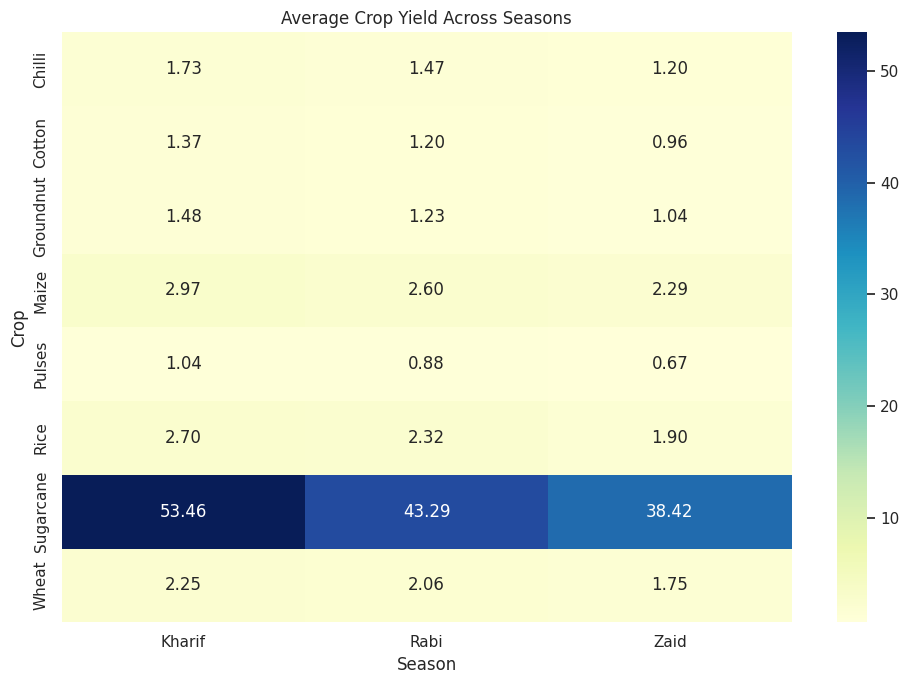

In [31]:
plt.figure(figsize=(10,7))

sns.heatmap(
    season_crop_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

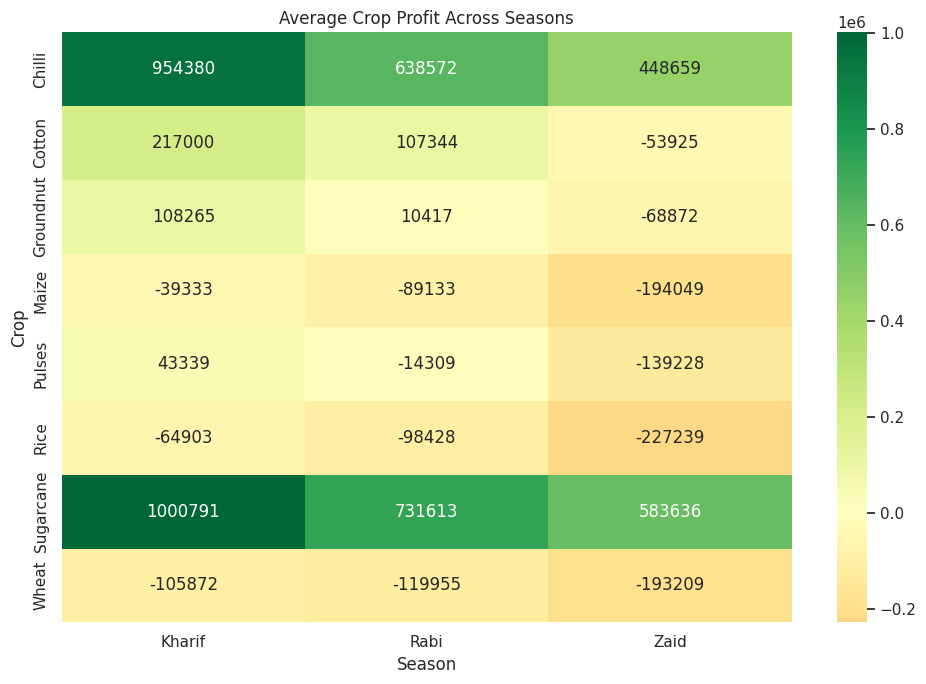

In [32]:
season_crop_profit = pd.pivot_table(
    df,
    values='Profit_INR',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

plt.figure(figsize=(10,7))

sns.heatmap(
    season_crop_profit,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=0
)

plt.title("Average Crop Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

In [33]:
features = [
    'Farm_Area_Hectares',
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

X = df[features]
y = df['Yield_Tonnes_Ha']

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 0.8068746875000001
RMSE: 2.6781158286231532
R² Score: 0.9627989431401877


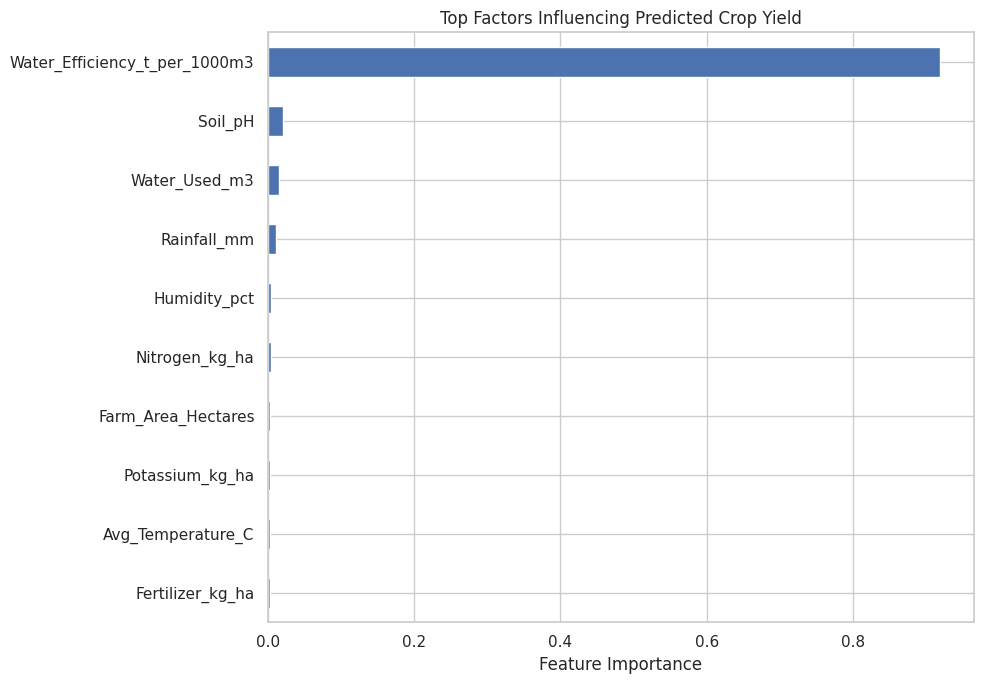

In [35]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(10,7))

importance.head(10).sort_values().plot(kind='barh')

plt.title("Top Factors Influencing Predicted Crop Yield")
plt.xlabel("Feature Importance")

plt.tight_layout()
plt.show()